# Q11 — Does visual content (photos) track popularity or rating? *(extended)*

Correlates each platform's photo count with its review volume and rating.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


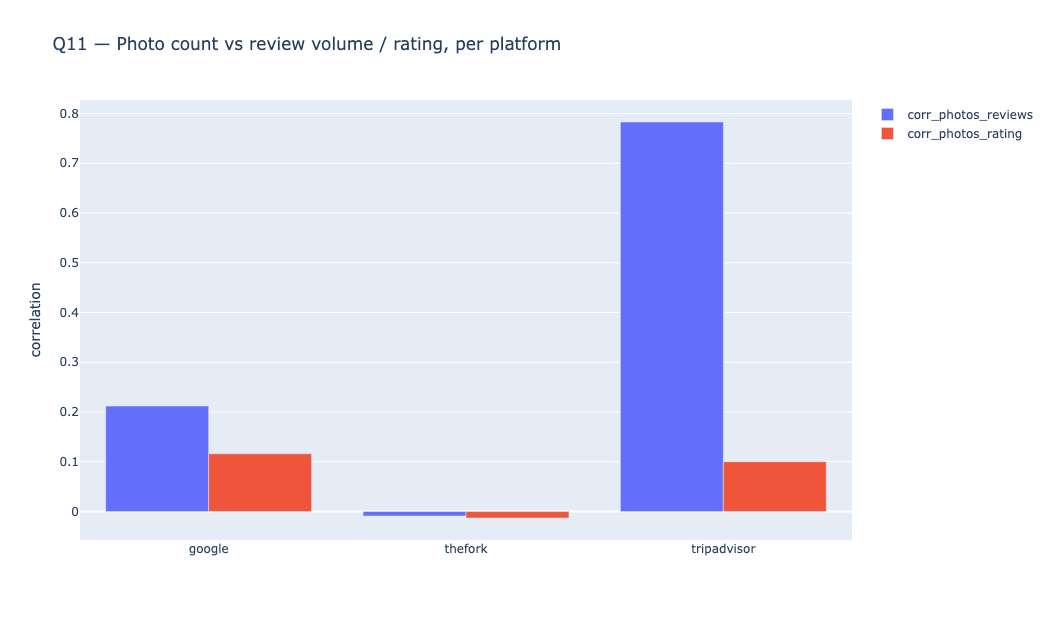

,platform,venues,corr_photos_reviews,corr_photos_rating
0,google,10054,0.212,0.116
1,thefork,908,-0.009,-0.013
2,tripadvisor,3282,0.783,0.100


In [2]:
q11 = publish(run(queries.q11_photo_correlations()), "q11_photo_correlations",
              "Q11 — Correlation of photo count with review volume and rating, per platform.")
fig = px.bar(q11, x="platform", y=["corr_photos_reviews", "corr_photos_rating"], barmode="group",
             labels={"value": "correlation", "platform": "", "variable": ""},
             title="Q11 — Photo count vs review volume / rating, per platform")
fig.show()
q11

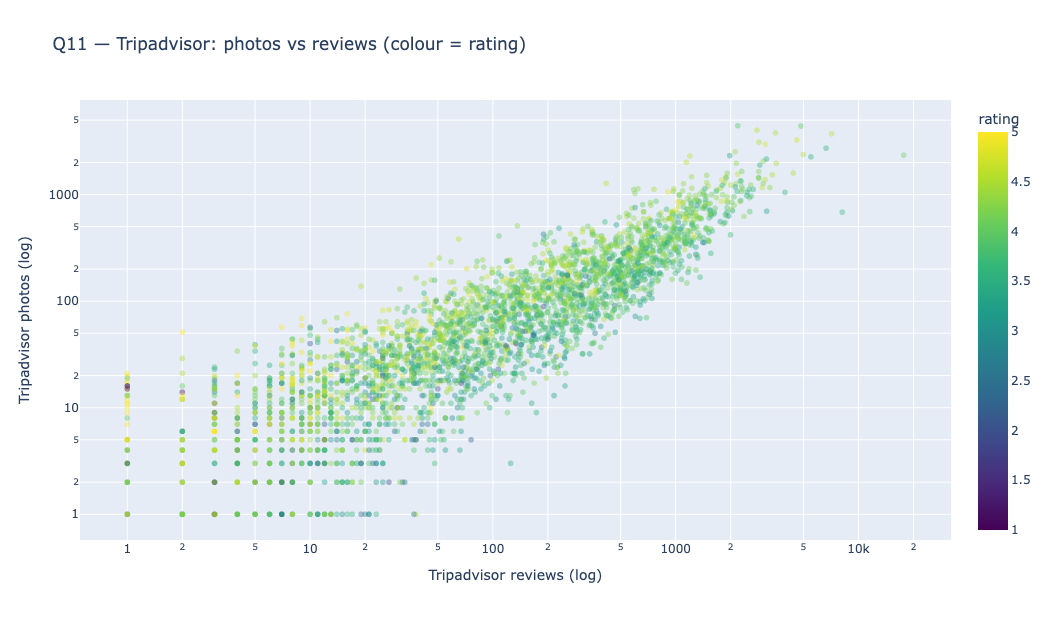

In [3]:
pr = run(queries.q11_photo_rows("tripadvisor"))
fig = px.scatter(pr, x="reviews", y="photos", color="rating", log_x=True, log_y=True,
                 opacity=0.4, color_continuous_scale="Viridis",
                 labels={"reviews": "Tripadvisor reviews (log)", "photos": "Tripadvisor photos (log)", "rating": "rating"},
                 title="Q11 — Tripadvisor: photos vs reviews (colour = rating)")
fig.show()

**Answer (Q11):** Photo richness tracks **popularity more than quality**. Photo count
correlates positively with review volume — strongly on Tripadvisor, moderately on Google —
but only weakly with rating (`q11_photo_correlations`). Visual content is a proxy for how
busy/established a venue is, not how good it is rated.